In [21]:
import sqlite3
import pandas as pd
import re
from pathlib import Path


REPO_ROOT = Path("/Users/neo/Projects/temple")
RUNS_CSV = REPO_ROOT / "experiments/cnv_reversion/manifests/runs.csv"


def decode_value(x):
    return float(x.replace("p", "."))


def parse_scenario_id(scenario_id):
    # example:
    # al__control__mp_0p001983__rev_0p05__cost_0p0005
    arm, policy, rest = scenario_id.split("__", 2)

    m = re.search(
        r"mp_(.*?)__rev_(.*?)__cost_(.*)$",
        rest
    )
    if not m:
        raise ValueError(f"Cannot parse scenario_id: {scenario_id}")

    return {
        "arm": arm,
        "policy": policy,
        "mutation_rate": decode_value(m.group(1)),
        "reversion_multiplier": decode_value(m.group(2)),
        "cnv_cost": decode_value(m.group(3)),
    }


def extract_output_path(command):
    # command looks like:
    # ./build/bin/MalaSim -i ... -o experiments/cnv_reversion/outputs/.../ -j 0
    m = re.search(r"\s-o\s+(\S+)\s+-j\s+(\d+)", command)
    if not m:
        raise ValueError(f"Cannot parse command: {command}")

    output_rel = m.group(1)
    job = int(m.group(2))
    return output_rel, job


def extract_gene_copies(genotype_name):
    """
    Extract:
    - pfmdr1_copies from the first 2-letter + number block after ||||
      Example: ||||YF1|| or ||||NF2||

    - pfplasmepsin_copies from the final pipe-number suffix
      Example: ...CRA|1 or ...YRA|2

    Supports copy numbers > 2.
    """

    pfmdr1_match = re.search(r"\|\|\|\|[A-Z]{2}(\d+)\|\|", genotype_name)
    if not pfmdr1_match:
        raise ValueError(f"Cannot parse pfmdr1 copies from: {genotype_name}")

    pfplas_match = re.search(r"\|(\d+)$", genotype_name)
    if not pfplas_match:
        raise ValueError(f"Cannot parse pfplasmepsin copies from: {genotype_name}")

    return {
        "pfmdr1_copies": int(pfmdr1_match.group(1)),
        "pfplasmepsin_copies": int(pfplas_match.group(1)),
    }

def load_one_db(db_path):
    conn = sqlite3.connect(db_path)

    geno = pd.read_sql_query("""
        SELECT monthly_data_id, location_id, genome_id, occurrences
        FROM monthly_genome_data_cell
    """, conn)

    time = pd.read_sql_query("""
        SELECT id, days_elapsed
        FROM monthly_data
    """, conn)

    genotype = pd.read_sql_query("""
        SELECT id, name
        FROM genotype
    """, conn)

    conn.close()

    df = geno.merge(time, left_on="monthly_data_id", right_on="id")
    df = df.merge(genotype, left_on="genome_id", right_on="id")

    copy_df = df["name"].apply(extract_gene_copies).apply(pd.Series)
    df = pd.concat([df, copy_df], axis=1)

    group_cols = ["days_elapsed", "location_id"]

    total = (
        df.groupby(group_cols)["occurrences"]
        .sum()
        .rename("total")
        .reset_index()
    )

    # pfmdr1 marginal frequencies
    pfmdr1 = (
        df.groupby(group_cols + ["pfmdr1_copies"])["occurrences"]
        .sum()
        .reset_index()
        .merge(total, on=group_cols, how="left")
    )

    pfmdr1["freq"] = pfmdr1["occurrences"] / pfmdr1["total"]

    pfmdr1_wide = (
        pfmdr1.pivot_table(
            index=group_cols,
            columns="pfmdr1_copies",
            values="freq",
            fill_value=0,
        )
        .rename(columns=lambda x: f"pfmdr1_copy_{int(x)}_freq")
        .reset_index()
    )

    # pfplasmepsin marginal frequencies
    pfplas = (
        df.groupby(group_cols + ["pfplasmepsin_copies"])["occurrences"]
        .sum()
        .reset_index()
        .merge(total, on=group_cols, how="left")
    )

    pfplas["freq"] = pfplas["occurrences"] / pfplas["total"]

    pfplas_wide = (
        pfplas.pivot_table(
            index=group_cols,
            columns="pfplasmepsin_copies",
            values="freq",
            fill_value=0,
        )
        .rename(columns=lambda x: f"pfplasmepsin_copy_{int(x)}_freq")
        .reset_index()
    )

    out = (
        total
        .merge(pfmdr1_wide, on=group_cols, how="left")
        .merge(pfplas_wide, on=group_cols, how="left")
    )

    freq_cols = [
        c for c in out.columns
        if c.endswith("_freq")
    ]

    out[freq_cols] = out[freq_cols].fillna(0)

    return out

def sqlite_is_readable(db_path):
    try:
        conn = sqlite3.connect(db_path)
        try:
            conn.execute("PRAGMA quick_check;").fetchone()
            conn.execute("SELECT name FROM sqlite_master LIMIT 1;").fetchone()
        finally:
            conn.close()
        return True

    except (sqlite3.DatabaseError, sqlite3.OperationalError) as e:
        print(f"Skipping malformed/unreadable DB: {db_path}")
        print(f"  Reason: {e}")
        return False
    

def sqlite_has_table(db_path, table_name):
    try:
        conn = sqlite3.connect(db_path)
        try:
            result = pd.read_sql_query(
                """
                SELECT name
                FROM sqlite_master
                WHERE type = 'table'
                  AND name = ?
                """,
                conn,
                params=(table_name,),
            )
        finally:
            conn.close()

        return not result.empty

    except (sqlite3.DatabaseError, sqlite3.OperationalError, pd.errors.DatabaseError) as e:
        print(f"Skipping malformed/unreadable DB during table check: {db_path}")
        print(f"  Reason: {e}")
        return False

def build_all_copy_number_table(
    runs_csv=RUNS_CSV,
    repo_root=REPO_ROOT,
    arm_filter=("al", "as_mq", "dha_ppq"),
    policy_filter=("control", "withdrawal"),
):
    runs = pd.read_csv(runs_csv)

    meta = pd.DataFrame([
        {
            **parse_scenario_id(row.scenario_id),
            "scenario_id": row.scenario_id,
            "command": row.command,
        }
        for row in runs.itertuples(index=False)
    ])

    parsed = runs["command"].apply(extract_output_path)
    runs["output_rel"] = [x[0] for x in parsed]
    runs["job"] = [x[1] for x in parsed]

    runs = runs.merge(
        meta.drop(columns=["command"]).drop_duplicates(),
        on="scenario_id",
        how="left",
    )

    runs = runs[
        runs["arm"].isin(arm_filter)
        & runs["policy"].isin(policy_filter)
    ].copy()

    all_parts = []

    required_tables = [
        "monthly_genome_data_cell",
        "monthly_data",
        "genotype",
    ]

    for row in runs.itertuples(index=False):
        db_path = repo_root / row.output_rel / f"monthly_data_{row.job}.db"

        if not db_path.exists():
            print(f"Missing: {db_path}")
            continue

        if not sqlite_is_readable(db_path):
            continue

        missing_tables = [
            table for table in required_tables
            if not sqlite_has_table(db_path, table)
        ]

        if missing_tables:
            print(f"Skipping DB with missing tables: {db_path}")
            print(f"  Missing: {', '.join(missing_tables)}")
            continue

        try:
            one = load_one_db(db_path)
        except (sqlite3.OperationalError, sqlite3.DatabaseError, pd.errors.DatabaseError, ValueError) as e:
            print(f"Skipping unreadable DB: {db_path}")
            print(f"  Reason: {e}")
            continue

        one["scenario_id"] = row.scenario_id
        one["job"] = row.job
        one["arm"] = row.arm
        one["policy"] = row.policy
        one["mutation_rate"] = row.mutation_rate
        one["reversion_multiplier"] = row.reversion_multiplier
        one["cnv_cost"] = row.cnv_cost

        all_parts.append(one)

    if not all_parts:
        raise RuntimeError("No DB files loaded.")

    return pd.concat(all_parts, ignore_index=True)

In [22]:
all_cnv = build_all_copy_number_table()
all_cnv.to_csv("all_cnv_frequencies.csv", index=False)

Skipping malformed/unreadable DB: /Users/neo/Projects/temple/experiments/cnv_reversion/outputs/dha_ppq/control/mp_0p001983__rev_0p2__cost_0p01/monthly_data_3.db
  Reason: database disk image is malformed
Missing: /Users/neo/Projects/temple/experiments/cnv_reversion/outputs/dha_ppq/control/mp_0p01__rev_0p4__cost_0p0005/monthly_data_7.db
Missing: /Users/neo/Projects/temple/experiments/cnv_reversion/outputs/dha_ppq/control/mp_0p01__rev_0p4__cost_0p0005/monthly_data_8.db
Missing: /Users/neo/Projects/temple/experiments/cnv_reversion/outputs/dha_ppq/control/mp_0p01__rev_0p4__cost_0p0005/monthly_data_9.db
Missing: /Users/neo/Projects/temple/experiments/cnv_reversion/outputs/dha_ppq/control/mp_0p01__rev_0p4__cost_0p001/monthly_data_0.db
Missing: /Users/neo/Projects/temple/experiments/cnv_reversion/outputs/dha_ppq/control/mp_0p01__rev_0p4__cost_0p001/monthly_data_1.db
Missing: /Users/neo/Projects/temple/experiments/cnv_reversion/outputs/dha_ppq/control/mp_0p01__rev_0p4__cost_0p001/monthly_data_

In [23]:
print(f"Loaded {len(all_cnv)} rows of CNV frequency data.")
print(f"{all_cnv.scenario_id.nunique()} unique scenario_ids.")
all_cnv.head()

Loaded 754324 rows of CNV frequency data.
357 unique scenario_ids.


,days_elapsed,location_id,total,pfmdr1_copy_1_freq,pfmdr1_copy_2_freq,pfplasmepsin_copy_1_freq,scenario_id,job,arm,policy,mutation_rate,reversion_multiplier,cnv_cost
0,0,0,99375,1.000000,0.000000,1.0,al__control__mp_0p001983__rev_0__cost_0p0005,0,al,control,0.001983,0.0,0.0005
1,31,0,104774,0.997223,0.002777,1.0,al__control__mp_0p001983__rev_0__cost_0p0005,0,al,control,0.001983,0.0,0.0005
2,60,0,131185,0.994862,0.005138,1.0,al__control__mp_0p001983__rev_0__cost_0p0005,0,al,control,0.001983,0.0,0.0005
3,91,0,164279,0.993188,0.006812,1.0,al__control__mp_0p001983__rev_0__cost_0p0005,0,al,control,0.001983,0.0,0.0005
4,121,0,196548,0.988313,0.011687,1.0,al__control__mp_0p001983__rev_0__cost_0p0005,0,al,control,0.001983,0.0,0.0005


In [24]:
import matplotlib.pyplot as plt
import re


def plot_copy_number_trajectories(
    all_cnv,
    arm="al",
    policy="control",
    mutation_rate=0.001983,
    cnv_cost=0.0005,
    location_id=0,
    gene="pfmdr1",
    copies=2,
    fallback_to_all_copies=True,
):
    gene_prefix_map = {
        "pfmdr1": "pfmdr1",
        "mdr1": "pfmdr1",
        "pfplasmepsin": "pfplasmepsin",
        "plasmepsin": "pfplasmepsin",
        "plas": "pfplasmepsin",
    }

    if gene not in gene_prefix_map:
        raise ValueError(
            f"Unknown gene: {gene}. Use 'pfmdr1' or 'pfplasmepsin'."
        )

    gene_prefix = gene_prefix_map[gene]

    # Example column names:
    # pfmdr1_copy_1_freq
    # pfplasmepsin_copy_3_freq
    freq_pattern = re.compile(rf"^{gene_prefix}_copy_(\d+)_freq$")

    copy_freq_cols = {}

    for col in all_cnv.columns:
        m = freq_pattern.match(col)
        if m:
            copy_number = int(m.group(1))
            copy_freq_cols[copy_number] = col

    if not copy_freq_cols:
        raise ValueError(
            f"No frequency columns found for {gene_prefix}. "
            f"Expected columns like '{gene_prefix}_copy_1_freq'."
        )

    available_copies = sorted(copy_freq_cols)

    # Filter scenario-level data first.
    sub = all_cnv[
        (all_cnv["arm"] == arm)
        & (all_cnv["policy"] == policy)
        & (all_cnv["mutation_rate"] == mutation_rate)
        & (all_cnv["cnv_cost"] == cnv_cost)
        & (all_cnv["location_id"] == location_id)
    ].copy()

    if sub.empty:
        print("No data for requested scenario.")
        print("Available combinations:")

        available = (
            all_cnv[
                ["arm", "policy", "mutation_rate", "cnv_cost", "location_id"]
            ]
            .drop_duplicates()
            .sort_values(
                ["arm", "policy", "mutation_rate", "cnv_cost", "location_id"]
            )
        )

        display(available.head(30))
        return None

    if copies not in available_copies:
        print(
            f"No column found for {gene_prefix} {copies} copies. "
            f"Available copy numbers: {available_copies}"
        )

        if not fallback_to_all_copies:
            return None

        print("Plotting all available copy numbers instead.")
        copies_to_plot = available_copies
    else:
        copies_to_plot = [copies]

    fig, ax = plt.subplots(figsize=(10, 5))

    for copy_number in copies_to_plot:
        freq_col = copy_freq_cols[copy_number]

        summary = (
            sub.groupby(["reversion_multiplier", "days_elapsed"])[freq_col]
            .agg(
                median="median",
                q10=lambda x: x.quantile(0.10),
                q90=lambda x: x.quantile(0.90),
            )
            .reset_index()
        )

        for rev in sorted(summary["reversion_multiplier"].unique()):
            s = summary[summary["reversion_multiplier"] == rev]

            if len(copies_to_plot) == 1:
                label = f"rev={rev:g}"
            else:
                label = f"{copy_number} copies, rev={rev:g}"

            ax.plot(
                s["days_elapsed"],
                s["median"],
                linewidth=2,
                label=label,
            )

            ax.fill_between(
                s["days_elapsed"],
                s["q10"],
                s["q90"],
                alpha=0.12,
            )

    if len(copies_to_plot) == 1:
        copy_title = f"{copies_to_plot[0]}-copy"
        y_label = f"{gene_prefix} {copies_to_plot[0]}-copy frequency"
    else:
        copy_title = "copy-number"
        y_label = f"{gene_prefix} copy-number frequency"

    ax.set_title(
        f"{gene_prefix} {copy_title} frequency over time | "
        f"{arm}, {policy}, mp={mutation_rate:g}, "
        f"cost={cnv_cost:g}, loc={location_id}"
    )

    ax.set_xlabel("Days elapsed")
    ax.set_ylabel(y_label)
    ax.legend(title="Trajectory", fontsize=8)

    plt.tight_layout()
    plt.show()

    return sub

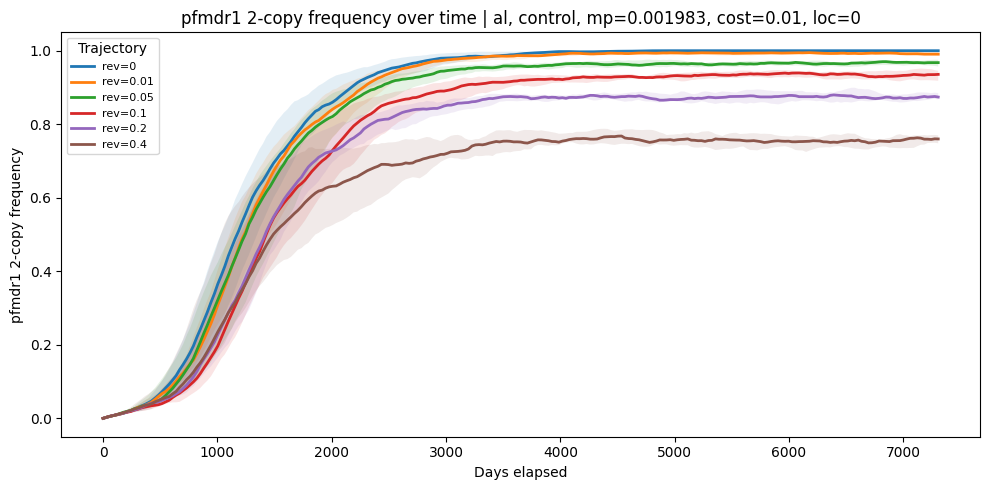

,days_elapsed,location_id,total,pfmdr1_copy_1_freq,pfmdr1_copy_2_freq,pfplasmepsin_copy_1_freq,scenario_id,job,arm,policy,mutation_rate,reversion_multiplier,cnv_cost
7230,0,0,99671,1.000000,0.000000,1.0,al__control__mp_0p001983__rev_0__cost_0p01,0,al,control,0.001983,0.0,0.01
7231,31,0,104493,0.997292,0.002708,1.0,al__control__mp_0p001983__rev_0__cost_0p01,0,al,control,0.001983,0.0,0.01
7232,60,0,131480,0.995269,0.004731,1.0,al__control__mp_0p001983__rev_0__cost_0p01,0,al,control,0.001983,0.0,0.01
7233,91,0,165489,0.992549,0.007451,1.0,al__control__mp_0p001983__rev_0__cost_0p01,0,al,control,0.001983,0.0,0.01
7234,121,0,197371,0.990753,0.009247,1.0,al__control__mp_0p001983__rev_0__cost_0p01,0,al,control,0.001983,0.0,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
57835,7183,0,409302,0.235633,0.764367,1.0,al__control__mp_0p001983__rev_0p4__cost_0p01,9,al,control,0.001983,0.4,0.01
57836,7213,0,411616,0.233978,0.766022,1.0,al__control__mp_0p001983__rev_0p4__cost_0p01,9,al,control,0.001983,0.4,0.01
57837,7244,0,414792,0.233170,0.766830,1.0,al__control__mp_0p001983__rev_0p4__cost_0p01,9,al,control,0.001983,0.4,0.01
57838,7274,0,416514,0.237034,0.762966,1.0,al__control__mp_0p001983__rev_0p4__cost_0p01,9,al,control,0.001983,0.4,0.01


In [25]:
plot_copy_number_trajectories(
    all_cnv,
    arm="al",
    policy="control",
    mutation_rate=0.001983,
    cnv_cost=0.01,
    location_id=0,
    gene="pfmdr1",
    copies=2
)

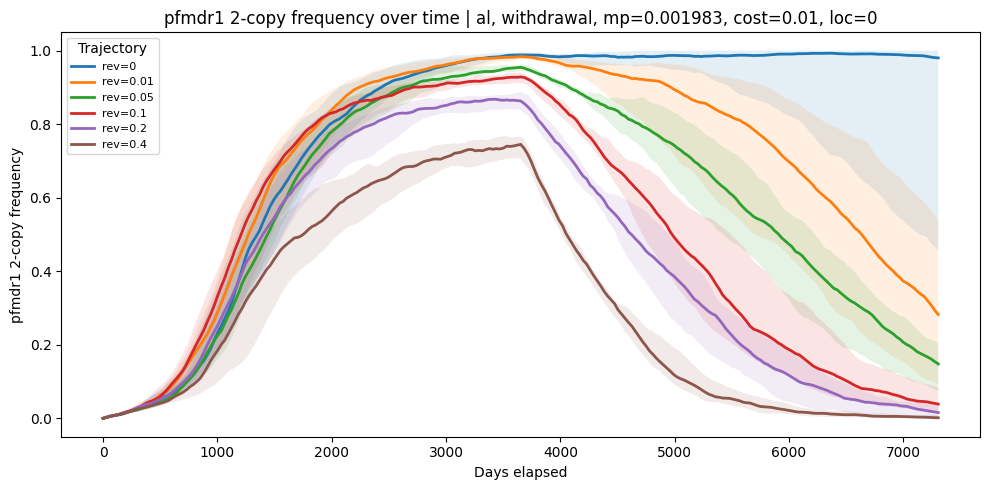

,days_elapsed,location_id,total,pfmdr1_copy_1_freq,pfmdr1_copy_2_freq,pfplasmepsin_copy_1_freq,scenario_id,job,arm,policy,mutation_rate,reversion_multiplier,cnv_cost
180750,0,0,100426,1.000000,0.000000,1.0,al__withdrawal__mp_0p001983__rev_0__cost_0p01,0,al,withdrawal,0.001983,0.0,0.01
180751,31,0,105029,0.995849,0.004151,1.0,al__withdrawal__mp_0p001983__rev_0__cost_0p01,0,al,withdrawal,0.001983,0.0,0.01
180752,60,0,132014,0.994296,0.005704,1.0,al__withdrawal__mp_0p001983__rev_0__cost_0p01,0,al,withdrawal,0.001983,0.0,0.01
180753,91,0,165276,0.992987,0.007013,1.0,al__withdrawal__mp_0p001983__rev_0__cost_0p01,0,al,withdrawal,0.001983,0.0,0.01
180754,121,0,196225,0.992396,0.007604,1.0,al__withdrawal__mp_0p001983__rev_0__cost_0p01,0,al,withdrawal,0.001983,0.0,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
231355,7183,0,326788,0.993666,0.006334,1.0,al__withdrawal__mp_0p001983__rev_0p4__cost_0p01,9,al,withdrawal,0.001983,0.4,0.01
231356,7213,0,326782,0.993950,0.006050,1.0,al__withdrawal__mp_0p001983__rev_0p4__cost_0p01,9,al,withdrawal,0.001983,0.4,0.01
231357,7244,0,326772,0.994736,0.005264,1.0,al__withdrawal__mp_0p001983__rev_0p4__cost_0p01,9,al,withdrawal,0.001983,0.4,0.01
231358,7274,0,326829,0.994847,0.005153,1.0,al__withdrawal__mp_0p001983__rev_0p4__cost_0p01,9,al,withdrawal,0.001983,0.4,0.01


In [26]:
plot_copy_number_trajectories(
    all_cnv,
    arm="al",
    policy="withdrawal",
    mutation_rate=0.001983,
    cnv_cost=0.01,
    location_id=0,
    gene="pfmdr1",
    copies=2,
)

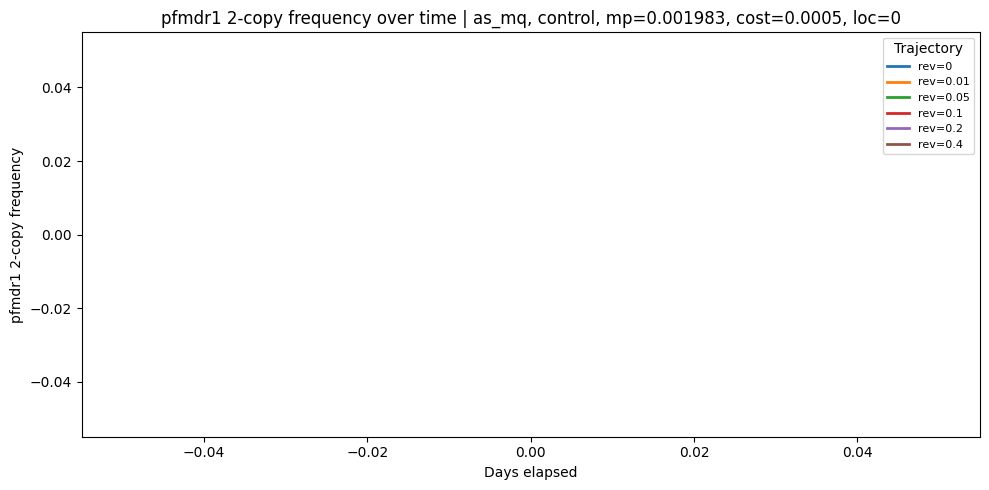

,days_elapsed,location_id,total,pfmdr1_copy_1_freq,pfmdr1_copy_2_freq,pfplasmepsin_copy_1_freq,scenario_id,job,arm,policy,mutation_rate,reversion_multiplier,cnv_cost
347040,0,0,99897,1.0,NaN,1.0,as_mq__control__mp_0p001983__rev_0__cost_0p0005,0,as_mq,control,0.001983,0.0,0.0005
347041,31,0,93150,1.0,NaN,1.0,as_mq__control__mp_0p001983__rev_0__cost_0p0005,0,as_mq,control,0.001983,0.0,0.0005
347042,60,0,93784,1.0,NaN,1.0,as_mq__control__mp_0p001983__rev_0__cost_0p0005,0,as_mq,control,0.001983,0.0,0.0005
347043,91,0,101740,1.0,NaN,1.0,as_mq__control__mp_0p001983__rev_0__cost_0p0005,0,as_mq,control,0.001983,0.0,0.0005
347044,121,0,110518,1.0,NaN,1.0,as_mq__control__mp_0p001983__rev_0__cost_0p0005,0,as_mq,control,0.001983,0.0,0.0005
...,...,...,...,...,...,...,...,...,...,...,...,...,...
397645,7183,0,153413,1.0,NaN,1.0,as_mq__control__mp_0p001983__rev_0p4__cost_0p0005,9,as_mq,control,0.001983,0.4,0.0005
397646,7213,0,153818,1.0,NaN,1.0,as_mq__control__mp_0p001983__rev_0p4__cost_0p0005,9,as_mq,control,0.001983,0.4,0.0005
397647,7244,0,154279,1.0,NaN,1.0,as_mq__control__mp_0p001983__rev_0p4__cost_0p0005,9,as_mq,control,0.001983,0.4,0.0005
397648,7274,0,154128,1.0,NaN,1.0,as_mq__control__mp_0p001983__rev_0p4__cost_0p0005,9,as_mq,control,0.001983,0.4,0.0005


In [27]:
plot_copy_number_trajectories(
    all_cnv,
    arm="as_mq",
    policy="control",
    mutation_rate=0.001983,
    cnv_cost=0.0005,
    location_id=0,
    gene="pfmdr1",
    copies=2,
)

No column found for pfplasmepsin 2 copies. Available copy numbers: [1]
Plotting all available copy numbers instead.


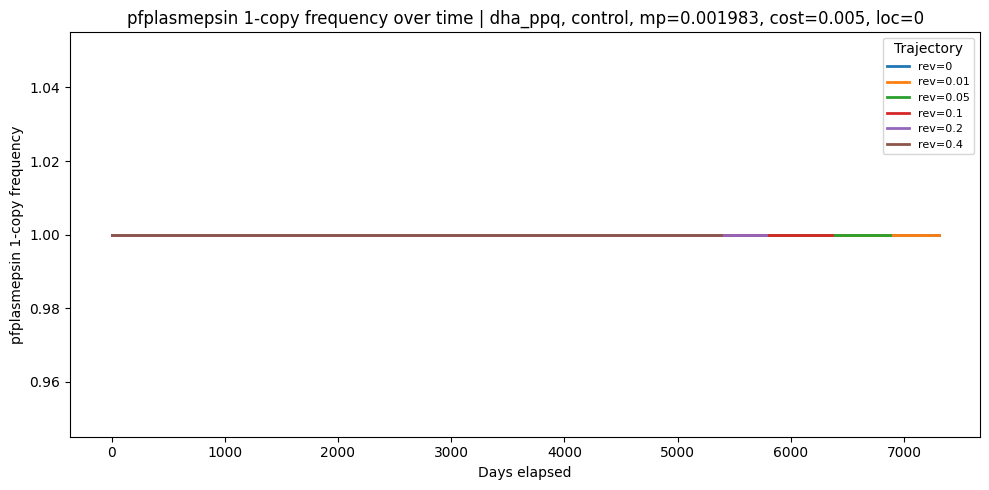

,days_elapsed,location_id,total,pfmdr1_copy_1_freq,pfmdr1_copy_2_freq,pfplasmepsin_copy_1_freq,scenario_id,job,arm,policy,mutation_rate,reversion_multiplier,cnv_cost
685553,0,0,99378,1.0,NaN,1.0,dha_ppq__control__mp_0p001983__rev_0__cost_0p005,0,dha_ppq,control,0.001983,0.0,0.005
685554,31,0,96374,1.0,NaN,1.0,dha_ppq__control__mp_0p001983__rev_0__cost_0p005,0,dha_ppq,control,0.001983,0.0,0.005
685555,60,0,102352,1.0,NaN,1.0,dha_ppq__control__mp_0p001983__rev_0__cost_0p005,0,dha_ppq,control,0.001983,0.0,0.005
685556,91,0,115472,1.0,NaN,1.0,dha_ppq__control__mp_0p001983__rev_0__cost_0p005,0,dha_ppq,control,0.001983,0.0,0.005
685557,121,0,127932,1.0,NaN,1.0,dha_ppq__control__mp_0p001983__rev_0__cost_0p005,0,dha_ppq,control,0.001983,0.0,0.005
...,...,...,...,...,...,...,...,...,...,...,...,...,...
720520,4322,0,155469,1.0,NaN,1.0,dha_ppq__control__mp_0p001983__rev_0p4__cost_0...,9,dha_ppq,control,0.001983,0.4,0.005
720521,4352,0,154981,1.0,NaN,1.0,dha_ppq__control__mp_0p001983__rev_0p4__cost_0...,9,dha_ppq,control,0.001983,0.4,0.005
720522,4383,0,155234,1.0,NaN,1.0,dha_ppq__control__mp_0p001983__rev_0p4__cost_0...,9,dha_ppq,control,0.001983,0.4,0.005
720523,4414,0,155735,1.0,NaN,1.0,dha_ppq__control__mp_0p001983__rev_0p4__cost_0...,9,dha_ppq,control,0.001983,0.4,0.005


In [30]:
plot_copy_number_trajectories(
    all_cnv,
    arm="dha_ppq",
    policy="control",
    mutation_rate=0.001983,
    cnv_cost=0.005,
    location_id=0,
    gene="pfplasmepsin",
    copies=2,
)